<a href="https://colab.research.google.com/github/Aswin-k61/NLP_Repo/blob/main/Spam_Mail_Pred.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [47]:
import pandas as pd
import string
import nltk

from nltk.corpus import stopwords
from nltk.stem import PorterStemmer

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
nltk.download('stopwords')


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [49]:
mail_data=pd.read_csv('/content/spam.csv')
mail_data.head()

,Category,Message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [48]:

mail_data['Category'] = mail_data['Category'].map({'ham': 0, 'spam': 1})
mail_data.head()


,Category,Message
0,NaN,"Go until jurong point, crazy.. Available only ..."
1,NaN,Ok lar... Joking wif u oni...
2,NaN,Free entry in 2 a wkly comp to win FA Cup fina...
3,NaN,U dun say so early hor... U c already then say...
4,NaN,"Nah I don't think he goes to usf, he lives aro..."


In [50]:
mail_data.isnull().sum()

,0
Category,0
Message,0


In [51]:
X=mail_data['Message']
y=mail_data['Category']

In [36]:
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)

In [52]:


def preprocess(text):
    text = text.lower()
    text = text.translate(str.maketrans('', '', string.punctuation))
    return text
vectorizer=TfidfVectorizer(preprocessor=preprocess,
stop_words='english',
lowercase=True)

In [53]:
X_train_features=vectorizer.fit_transform(X_train)
X_test_features=vectorizer.transform(X_test)

In [54]:
model=LogisticRegression()
model.fit(X_train_features,y_train)

LogisticRegression()

In [55]:
from sklearn.metrics import accuracy_score
y_pred_train=model.predict(X_train_features)
print("Training Accuracy",accuracy_score(y_train,y_pred_train))
y_pred_test=model.predict(X_test_features)
print("Testing Accuracy",accuracy_score(y_test,y_pred_test))

Training Accuracy 0.9645501458380076
Testing Accuracy 0.9641255605381166


In [56]:
input_mail = ["Congratulations! You have won a free lottery"]
input_data_features = vectorizer.transform(input_mail)
prediction = model.predict(input_data_features)
if prediction[0] == 1:
  print("Spam Mail")
else:
  print("Ham Mail")

Spam Mail


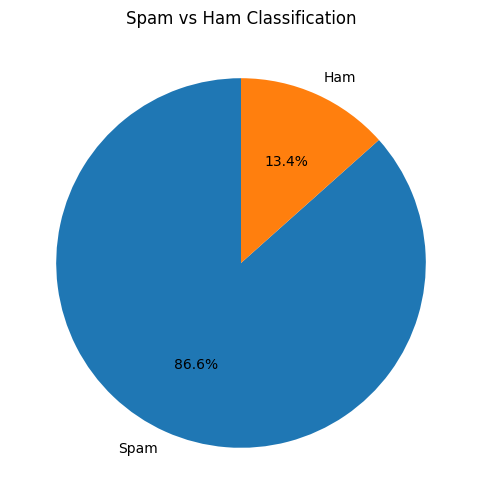

In [57]:
import matplotlib.pyplot as plt
plt.figure(figsize=(6,6))
plt.pie(mail_data['Category'].value_counts(),labels=['Spam','Ham'],autopct='%1.1f%%',startangle=90)
plt.title("Spam vs Ham Classification")
plt.show()